#### 훈련세트 크기 - 정확도 학습 곡선
- <img src="img/zh.png" alt="image.png" style="width:750px;" />
- 훈련세트 크기가 클수록 훈련세트에서의 정확도는 낮아지지만 검증세트의 정확도는 올라간다. 그래도 검증세트 정확도가 훈련 세트 정확도를 넘진 않는다.

- <img src="img/zi.png" alt="image.png" style="width:750px;" />
- 모델 복잡도가 클수록 훈련 세트 손실과 검증 세트 손실은 감소한다. 하지만 이후 복잡도가 더욱 커지면 훈련 세트의 노이즈까지 학습하기 때문에 검증 데이터의 손실은 증가한다.
- 모델 복잡도가 클수록 훈련 세트 정확도는 증가한다. 하지만 이후 복잡도가 더욱 커지면 훈련 세트의 노이즈까지 학습하기 때문에 검증 데이터의 정확도는 감소한다.

#### 편향-분산 트레이드오프(bias-variance tradeoff)
- 과소적합된 모델은 **'편향되었다'**, 과대적합된 모델은 **'분산이 크다'**
- 이 둘 사이의 관계를 편향-분산 트레이드오프 라고 함.
- 적절한 편향-분산 트레이드오프 선택이 필요

455 114
(array([0, 1]), array([212, 357], dtype=int64))
364 91
0.967032967032967


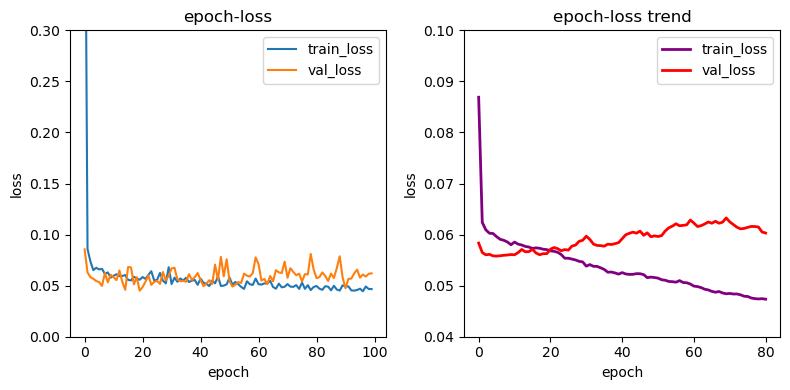

In [33]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

class SingleLayer:
    def __init__(self, learning_rate=0.1):
        self.w = None
        self.b = None
        self.losses = []
        self.val_losses = []
        self.w_history = []
        self.lr = learning_rate

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z
    
    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad
    
    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.w = np.ones(x.shape[1])
        self.b = 0
        self.w_history.append(self.w.copy())
        np.random.seed(42)
        for i in range(epochs):
            loss = 0
            indexes = np.random.permutation(np.arange(len(x)))
            for i in indexes:
                z = self.forpass(x[i])
                a = self.activation(z)
                err = -(y[i] - a)
                w_grad, b_grad = self.backprop(x[i], err)
                self.w -= self.lr * w_grad
                self.b -= b_grad
                self.w_history.append(self.w.copy())
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a) + (1-y[i])*np.log(1-a))
            self.losses.append(loss/len(y))
            self.update_val_loss(x_val, y_val)

    
    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        return np.array(z) > 0
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y)

    def update_val_loss(self, x_val, y_val):
        if x_val is None:
            return
        val_loss = 0
        for i in range(len(x_val)):
            z = self.forpass(x_val[i])
            a = self.activation(z)
            a = np.clip(a, 1e-10, 1-1e-10)
            val_loss += -(y_val[i]*np.log(a) + (1-y_val[i])*np.log(1-a))
        self.val_losses.append(val_loss/len(y_val))
    

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(np.unique(cancer.target, return_counts=True))
print(len(x_train), len(x_val))

train_mean = np.mean(x_train, axis=0)
train_std = np.std(x_train, axis=0)
x_train_scaled = (x_train - train_mean) / train_std

# val_mean = np.mean(x_val, axis=0)
# val_std = np.std(x_val, axis=0)
x_val_scaled = (x_val - train_mean) / train_std

layer = SingleLayer()
layer.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val=y_val)

print(layer.score(x_val_scaled, y_val))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].set_title("epoch-loss")
axes[0].set_ylim(0, 0.3)
axes[0].plot(layer.losses)
axes[0].plot(layer.val_losses)
axes[0].set_ylabel('loss')
axes[0].set_xlabel('epoch')
axes[0].legend(['train_loss', 'val_loss'])

def moving_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

axes[1].set_title("epoch-loss trend")
axes[1].set_ylim(0.04, 0.1)
axes[1].plot(moving_average(layer.losses), label='train_loss_trend', color='purple', linewidth=2)
axes[1].plot(moving_average(layer.val_losses), label='val_loss_trend', color='red', linewidth=2)
axes[1].set_ylabel('loss')
axes[1].set_xlabel('epoch')
axes[1].legend(['train_loss', 'val_loss'])

plt.tight_layout()
plt.show()

#### 일반화
- 일반화 성능: 임의의 데이터를 더 잘 표현하는 모델의 성능

- But 모델이 특정 데이터 세이트에 너무 적합하면(과적합) 일반화 성능이 떨어짐.

#### 데이터 증식(증강, Data Augmentation) 기법
데이터 양이 적은 경우
- 해당 데이터의 특정 패턴이나 노이즈까지 암기(과적합)
- 의도적으로 기존 데이터를 조금씩 변형하고 추가하여 데이터양을 늘리는 데이터 증강 기법 사용
    - 이미지의 경우 이미지 회전/노이즈 추가/일부 수정 등의 방식으로 데이터 증식
    - 텍스트의 경우 번역 후 재번역하는 역번역(Back Translation) 등의 방식 사용

#### 모델의 복잡도
- 인공신경망의 복잡도는 은닉층의 수나 매개변수의 수 등으로 결정
- 과적합 시 복잡도를 줄이는 조치 필요(**가중치 규제**)

### 가중치 규제 적용(Regularization)
- 복잡한 모델을 간단하게 하는 방법
1) L1 규제
    - 가중치 $w$들의 절댓값 합계를 비용합수에 추가(L1 노름(norm) $= \sum^{n}_{i=1}|w_i|$)
    - 기존의 비용 함수의 모든 가중치에 대하여 $+\lambda |w|$ 한 값을 비용함수로 설정
    - $\lambda$ 는 규제의 강도를 정하는 하이퍼파라미터
    - $\lambda$ 가 크면 모델 우선순위: (훈련데이터에 대한 적합한 매개 변수 탐색) < (규제를 위해 추가된 항들($\lambda |w|$을 작게 유지)
    - L1 규제를 사용하면 비용 합수가 최소가 되는 가중치와 편향 찾기 + 가중치들의 절댓값의 합도 최소 필요
    - 어떤 $w$ 값은 0 또는 0에 가까워짐(거의 사용하지 않는 특성이 생김)

    - $L = -(y log(a) + (1-y)log(1-a)) + \lambda \sum^{n}_{i=1}|w_i|$
    - $\frac {\partial} {\partial w}L = -(y-a)x + \lambda \sum^{n}_{i=1} sign(w)$ <-- $\lambda$에 크게 의존함($sign(w)$ 는 부호함수)

2) L2 규제
    - 모든 가중치 $w$들의 제곱합을 비용함수에 추가(L2 노름)
    - 기존의 비용 함수의 모든 가중치에 대하여 $+\frac{1} {2}\lambda w^2$ 한 값을 비용함수로 설정
    - L1 규제와는 달리 제곱을 최소화하므로 $w$ 값이 0이 되기보다는 0에 가까워지는 경향성을 가짐
    - $L = -(y log(a) + (1-y)log(1-a)) + \frac{1} {2}\lambda w^2$
    - $\frac {\partial} {\partial w}L = -(y-a)x + \lambda \sum^{n}_{i=1} w$
    - 가중치 감쇠(weight decay) 라고도 부름

- L1 규제는 어떤 특성들이 모델에 영향을 주고 있는지를 정확히 판단하고자 할 때 유용
- 경험적으로, L2규제가 더 잘 작동(권장),


455 114
(array([0, 1]), array([212, 357], dtype=int64))
364 91
0.6666666666666666
0.3333333333333333
0.13333333333333333
0.1


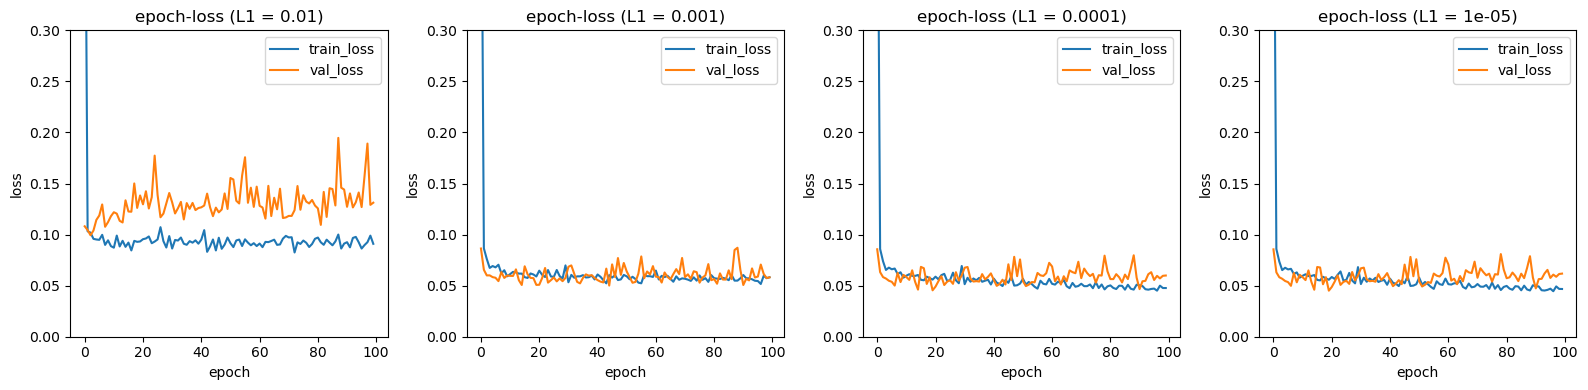

In [51]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

class SingleLayer:
    def __init__(self, learning_rate=0.1, l1=0, l2=0):
        self.w = None
        self.b = None
        self.losses = []
        self.val_losses = []
        self.w_history = []
        self.lr = learning_rate

        self.l1 = l1
        self.l2 = l2 # l1, l2 추가

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b
        return z
    
    def backprop(self, x, err):
        w_grad = x * err
        b_grad = 1 * err
        return w_grad, b_grad
    
    def activation(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.w = np.ones(x.shape[1])
        self.b = 0
        self.w_history.append(self.w.copy())
        np.random.seed(42)
        for i in range(epochs):
            loss = 0
            indexes = np.random.permutation(np.arange(len(x)))
            for i in indexes:
                z = self.forpass(x[i])
                a = self.activation(z)
                err = -(y[i] - a)
                w_grad, b_grad = self.backprop(x[i], err)

                w_grad += self.l1*np.sign(self.w) + self.l2 * self.w # L1, L2 규제 항 추가

                self.w -= self.lr * w_grad
                self.b -= b_grad
                self.w_history.append(self.w.copy())
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a) + (1-y[i])*np.log(1-a))
            self.losses.append(loss/len(y))
            self.update_val_loss(x_val, y_val)

    
    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]
        return np.array(z) > 0
    
    def score(self, x, y):
        return np.mean(self.predict(x) == y)

    def reg_loss(self):
        return self.l1 * np.sum(np.abs(self.w)) + self.l2 / 2*np.sum(self.w**2) # L1, L2 계산

    def update_val_loss(self, x_val, y_val):
        if x_val is None:
            return
        val_loss = 0
        for i in range(len(x_val)):
            z = self.forpass(x_val[i])
            a = self.activation(z)
            a = np.clip(a, 1e-10, 1-1e-10)
            val_loss += -(y_val[i]*np.log(a) + (1-y_val[i])*np.log(1-a))
        self.val_losses.append(val_loss/len(y_val))
    

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(len(x_train_all), len(x_test))
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
print(np.unique(cancer.target, return_counts=True))
print(len(x_train), len(x_val))

train_mean = np.mean(x_train, axis=0)
train_std = np.std(x_train, axis=0)
x_train_scaled = (x_train - train_mean) / train_std

x_val_scaled = (x_val - train_mean) / train_std

l1 = [ # L1 규제 추가
    0.1, 0.01, 0.001
]    

n = 4

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

for i in range(n):
    l1 = 10**(-(i + 2))
    layer = SingleLayer(l1 = l1)
    layer.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val=y_val)

    axes[i].set_title(f"epoch-loss (L1 = {l1})")
    axes[i].set_ylim(0.0, 0.3)
    axes[i].plot(layer.losses)
    axes[i].plot(layer.val_losses)
    axes[i].set_ylabel('loss')
    axes[i].set_xlabel('epoch')
    axes[i].legend(['train_loss', 'val_loss'])

    print(np.mean(np.abs(layer.w) < 0.1)) # L1 규제가 작아질수록 0에 가까워진 w 값이 줄어든다


plt.tight_layout()
plt.show()